# Clustering Optimization

Optimize DBSCAN using a small batch of test files

In [1]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import os, sys
import traceback
import glob
import pandas as pd

import h5flow 
plt.style.use('../../utils/dune.mplstyle')
from sklearn.cluster import DBSCAN

# Path to repo root (two directories above notebook)
light_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(light_root)

from light.PMT_analysis_utils import * 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

# TODO: Delete redundant packages

### Generate a batch of MC+No Source overlayed data

In [2]:
# Load MC

def load_MC(MC_file):

    '''
    Load MC data into a dataframe
    '''

    file_id = 0
    mc_hit_arr = np.empty(9)

    # Load MC
    for file in glob.iglob(MC_file):
        with h5.File(file, 'r') as f:
            traj = f['mc_truth/trajectories/data']
            seg = f['mc_truth/segments/data']
            for event_id in np.unique(traj['event_id']):
                my_entry = event_id-1
                ev_traj= traj[traj['event_id']==event_id]
                ev_seg= seg[seg['event_id']==event_id]
                prompt_hits_backtrack, prompt_hits = get_charge_event_hits(my_entry,f)
                new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)

                # Exclude negative hits
                positive_hits = new_hits[new_hits['E']>=0]

                # Use parent neutron id as light trigger id since they should correspond with each pmt id from data
                # All cluster ids are -2 for now as placeholder
                # All ids are 'nan' for now as placeholder
                mc_hit_arr = np.vstack([mc_hit_arr, np.column_stack([positive_hits['x'], positive_hits['y'], positive_hits['z'], positive_hits['E'], positive_hits['Q'], 1.0*positive_hits['parent_neutron_id'], -2*np.ones(len(positive_hits['x'])), file_id*np.ones(len(positive_hits['x'])), np.full(len(positive_hits['x']),fill_value='nan')])])
            file_id += 1

    mc_df = pd.DataFrame(mc_hit_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id'])
    return mc_df

In [3]:
# Get a small batch of cosmic & MC data
cosmic_data = '/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv'
MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/*.hdf5'

In [4]:
MC_df = load_MC(MC_data)

In [5]:
def charge_to_energy_mev(charge_ke):
    return (np.asarray(charge_ke, dtype=np.float64) * 1e3 * 23.6) / 0.57523585 / 1e6

In [6]:
# Recalibrate energy
MC_df['E'] = charge_to_energy_mev(MC_df['Q'])

In [7]:
def only_overlay_MC_Cosmic(cosmic_file, mc_df, clust_eps=1,clust_min_samples=4):
    '''
    Overlap each MC event (currently without light info) with a cosmic event to generate a new dataframe
    
    If there are less cosmic triggers than MC events there will be a notice of how many events were successfully overlapped

    Overlay dataframes will contain an extra column flagging which events were overlaid (overlay_label = 1) vs which event is just from a no source trigger (overlay_label = 0)

    Also include a flag differentiating the cluster and the MC with the column name "is_MC"

    No reclustering will be done

    '''
    cosmic_df = pd.read_csv(cosmic_file, index_col=0)

    # Recalibrate hit energy
    cosmic_df['E'] = charge_to_energy_mev(cosmic_df['Q'])

    mc_df.loc[:, 'is_MC'] = 1
    cosmic_df.loc[:, 'is_MC'] = 0

    mc_hit_trig_ids = mc_df['file_id'].astype(str) + '::' + mc_df['light_id'].astype(str)
    mc_hit_trig_ids_unique = np.unique(mc_hit_trig_ids)
    # Generate a list of cosmic trig ids that have hits in them
    cosmic_og_trig_ids = cosmic_df['file_id'].astype(str)+ '::' + cosmic_df['light_id'].astype(str)
    cosmic_og_trig_ids_wclusters = np.array(cosmic_og_trig_ids[cosmic_df['cluster_label']!=-1])
    cosmic_og_trig_ids_wclusters_unique = np.unique(cosmic_og_trig_ids_wclusters)

    print('begin overlay')

    snr = 0.1    # Signal to Noise Ratio: Number of MC events / Number of background events
    # Empty array for overlays
    overlay_arr = np.empty(11)
    for i in range(min([len(mc_hit_trig_ids_unique), len(cosmic_og_trig_ids_wclusters_unique)])):
        cosmic_temp = cosmic_df[cosmic_og_trig_ids==cosmic_og_trig_ids_wclusters_unique[i]]
        # Change file and light ids of the cosmic trigs
        cosmic_temp.loc[:,'file_id'] = float(mc_hit_trig_ids_unique[i].split('::')[0])
        cosmic_temp.loc[:,'light_id'] = float(mc_hit_trig_ids_unique[i].split('::')[1])
        if snr*i%1==0:
            arr_to_stack = np.vstack([mc_df[mc_hit_trig_ids==mc_hit_trig_ids_unique[i]], cosmic_temp])
            arr_to_stack = np.column_stack([arr_to_stack, np.ones(len(arr_to_stack)).T])
            overlay_arr = np.vstack([overlay_arr, arr_to_stack])
        else:
            # pass through the process without overlaying an event
            arr_to_stack = np.column_stack([cosmic_temp, np.zeros(len(cosmic_temp)).T])
            overlay_arr = np.vstack([overlay_arr, arr_to_stack])

    # Eliminate the empty first row of the array
    overlay_arr = overlay_arr[1:]
    # Convert the overlayed array to a dataframe
    overlay_df = pd.DataFrame(overlay_arr, columns=['x', 'y', 'z', 'E', 'Q', 'light_id', 'cluster_label', 'file_id', 'id', 'is_MC', 'overlay_label'])

    # temporarily change all cluster labels to -2
    overlay_df['cluster_label'] = -2

    final_overlay_df = overlay_df
    final_overlay_df['id']=final_overlay_df['file_id'].astype(str) +'::'+ final_overlay_df['light_id'].astype(str) +'::'+ final_overlay_df['cluster_label'].astype(str)
    print(f'Total number of neutrons in MC file: {len(np.unique(mc_hit_trig_ids))}')
    print(f'Total number of overlay events generated: {len(np.unique(final_overlay_df["file_id"].astype(str) +"::"+ final_overlay_df["light_id"].astype(str)))}')
    print(f'Total number of hits in all overlayed events: {len(final_overlay_df["file_id"])}')
    return final_overlay_df

In [8]:
# Perform overlay

df_nosource_MC_overlay_no_clust = only_overlay_MC_Cosmic(cosmic_data, MC_df)

begin overlay
Total number of neutrons in MC file: 1579
Total number of overlay events generated: 1067
Total number of hits in all overlayed events: 20517


In [9]:
df_nosource_MC_overlay_no_clust

,x,y,z,E,Q,light_id,cluster_label,file_id,id,is_MC,overlay_label
0,3.2933985442186158,-61.4109001159668,-33.72169876098633,0.048317,1.1776911650018531,-1.0,-2,0.0,0.0::-1.0::-2,1,1.0
1,47.71014973036264,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,-2,0.0,0.0::-1.0::-2,1,1.0
2,47.263143035359434,53.4296989440918,19.532899856567383,0.068432,1.667995249547487,-1.0,-2,0.0,0.0::-1.0::-2,1,1.0
3,41.49994957478246,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,-2,0.0,0.0::-1.0::-2,1,1.0
4,39.71192279476966,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,-2,0.0,0.0::-1.0::-2,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
20512,64.585545,60.524101,-45.250099,0.749009,18.256639,2.0,-2,61.0,61.0::2.0::-2,0,0.0
20513,64.505723,60.0807,-43.919899,0.308582,7.521504,2.0,-2,61.0,61.0::2.0::-2,0,0.0
20514,64.409936,59.637299,-43.919899,0.729448,17.779864,2.0,-2,61.0,61.0::2.0::-2,0,0.0
20515,63.962929,59.637299,-43.919899,0.769607,18.758702,2.0,-2,61.0,61.0::2.0::-2,0,0.0


In [10]:
# Perform clustering with a range of parameters
def cluster_df(df, clust_eps, clust_min_samples):
    db = DBSCAN(eps=clust_eps,min_samples=clust_min_samples)
    evt_ids = df['file_id'].to_numpy().astype(str) + '::' + df['light_id'].to_numpy().astype(str)

    # Performance parameters
    efficiency = []
    purity = []

    for i in np.unique(evt_ids):
        evt_hits = df[evt_ids==i]
        labels = db.fit_predict(evt_hits[['x', 'y', 'z']].to_numpy())
        df.loc[evt_ids==i, 'cluster_label'] = labels
        # Calculate performance parameters
        if len(evt_hits[evt_hits['is_MC']==1]) and len(labels[labels!=-1]):
            efficiency.append(len(labels[(labels!=-1) & (evt_hits['is_MC']==1)])/len(evt_hits[evt_hits['is_MC']==1]))
            purity.append(len(labels[(labels!=-1) & (evt_hits['is_MC']==1)])/len(labels[labels!=-1]))
        else:
            pass

    # update all ids
    df['id'] = df['file_id'].astype(str) +'::'+ df['light_id'].astype(str) +'::'+ df['cluster_label'].astype(str)

    return np.mean(efficiency), np.mean(purity)

In [22]:
cluster_df(df_nosource_MC_overlay_no_clust, 6, 1)

(np.float64(1.0), np.float64(0.6127748047563201))

In [23]:
df_nosource_MC_overlay_no_clust

,x,y,z,E,Q,light_id,cluster_label,file_id,id,is_MC,overlay_label
0,3.2933985442186158,-61.4109001159668,-33.72169876098633,0.048317,1.1776911650018531,-1.0,0,0.0,0.0::-1.0::0,1,1.0
1,47.71014973036264,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,1,0.0,0.0::-1.0::1,1,1.0
2,47.263143035359434,53.4296989440918,19.532899856567383,0.068432,1.667995249547487,-1.0,1,0.0,0.0::-1.0::1,1,1.0
3,41.49994957478246,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,1,0.0,0.0::-1.0::1,1,1.0
4,39.71192279476966,53.4296989440918,19.532899856567383,0.029806,0.7265043439747367,-1.0,1,0.0,0.0::-1.0::1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
20512,64.585545,60.524101,-45.250099,0.749009,18.256639,2.0,0,61.0,61.0::2.0::0,0,0.0
20513,64.505723,60.0807,-43.919899,0.308582,7.521504,2.0,0,61.0,61.0::2.0::0,0,0.0
20514,64.409936,59.637299,-43.919899,0.729448,17.779864,2.0,0,61.0,61.0::2.0::0,0,0.0
20515,63.962929,59.637299,-43.919899,0.769607,18.758702,2.0,0,61.0,61.0::2.0::0,0,0.0


In [ ]:
print(len(df_nosource_MC_overlay_no_clust[df_nosource_MC_overlay_no_clust['is_MC']==1])/len(df_nosource_MC_overlay_no_clust[df_nosource_MC_overlay_no_clust['']==1.0]))

0.763952645566562


In [25]:
# Plot distribution of cluster size

clust_ids = df_nosource_MC_overlay_no_clust['id'][df_nosource_MC_overlay_no_clust['overlay_label']==1.0]

/tmp/ipykernel_1020482/3760373306.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


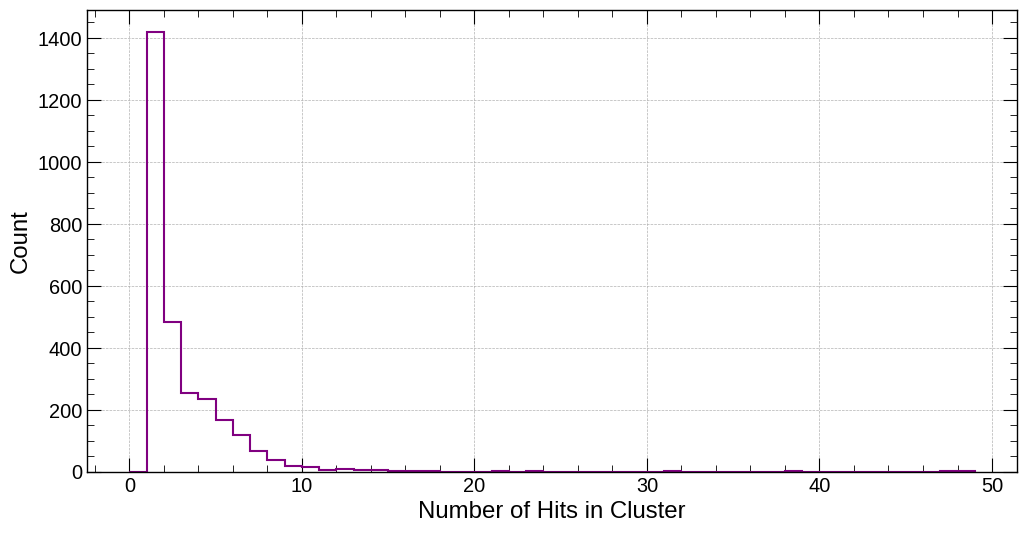

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(np.unique(clust_ids, return_counts=True)[1], bins=np.arange(0,50,1), color='purple', histtype='step')

plt.xlabel('Number of Hits in Cluster')
plt.ylabel('Count')
plt.grid(True)
#plt.yscale('log')
#plt.ylim((0,50))
plt.show()

In [ ]:
# List of DBSCAN parameters

eps_li = np.arange(1,11,1)
min_clust_li = np.arange(1,20,2)

In [ ]:
avg_eff_per_evt = []
avg_pur_per_evt = []

for m in min_clust_li:
    for n in eps_li:
        eff,pur = cluster_df(df_nosource_MC_overlay_no_clust, n, m)
        avg_eff_per_evt.append(eff)
        avg_pur_per_evt.append(pur)

In [ ]:
# Generate a 2d histogram of the efficiency and purity

# Turn the list of effciency and purity into 2d arrays
# eps varies across rows, cluster size vary across columns

eff_array = np.reshape(avg_eff_per_evt, (len(min_clust_li), len(eps_li)))
pur_array = np.reshape(avg_pur_per_evt, (len(min_clust_li), len(eps_li)))


# Efficiency
plt.figure(figsize=(10, 10))
plt.imshow(eff_array, origin='lower')
plt.colorbar(label='Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(min_clust_li),1), labels=min_clust_li)
plt.xticks(ticks=np.arange(0,len(eps_li),1), labels=eps_li)
#plt.title('Average Efficiency per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(min_clust_li)):
    for j in range(len(eps_li)):
        text = plt.text(j, i, eff_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()


# Purity
plt.figure(figsize=(10, 10))
plt.imshow(pur_array, origin='lower')
plt.colorbar(label='Purity')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(min_clust_li),1), labels=min_clust_li)
plt.xticks(ticks=np.arange(0,len(eps_li),1), labels=eps_li)
#plt.title('Average Purity per Event')
plt.grid(True)

# Loop over data dimensions and create text annotations.
for i in range(len(min_clust_li)):
    for j in range(len(eps_li)):
        text = plt.text(j, i, pur_array[i, j].round(3),
                       ha="center", va="center", color="w")

plt.show()

# Purity*Efficiency
plt.imshow(pur_array*eff_array, origin='lower')
plt.colorbar(label='Purity*Efficiency')
plt.xlabel('eps (cm)')
plt.ylabel('Minimum Cluster Size (# of Hits)')
plt.yticks(ticks=np.arange(0,len(min_clust_li),1), labels=min_clust_li)
plt.xticks(ticks=np.arange(0,len(eps_li),1), labels=eps_li)
#plt.title('Purity*Efficiency per Event')
plt.grid(True)
plt.show()